<a href="https://colab.research.google.com/github/Otza02/satellite-img-segmentation/blob/main/notebooks/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Otza02/satellite-img-segmentation.git
%cd satellite-img-segmentation
!pip install -e .

Cloning into 'satellite-img-segmentation'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 115 (delta 45), reused 90 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 874.23 KiB | 16.81 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/satellite-img-segmentation
Obtaining file:///content/satellite-img-segmentation
  Preparing metadata (setup.py) ... done
  Running setup.py develop for satelliteSegmentation


In [ ]:
%cd /content/satellite-img-segmentation
!unzip -q data/processed.zip -d data/processed

In [ ]:
from satelliteSegmentation.config import Config
from satelliteSegmentation.dataset import load_data, SatelliteData
from satelliteSegmentation.models.unet import UNet
from satelliteSegmentation.train import train_model, run_one_epoch

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

In [5]:
data_train = load_data("train")
data_val = load_data("val")

100%|██████████| 5184/5184 [00:09<00:00, 560.66it/s]


Dataset cargado:
X shape = torch.Size([5184, 3, 120, 120])
Y shape = torch.Size([5184, 120, 120])


100%|██████████| 648/648 [00:01<00:00, 589.71it/s]


Dataset cargado:
X shape = torch.Size([648, 3, 120, 120])
Y shape = torch.Size([648, 120, 120])


In [6]:
conf = Config("cuda" if torch.cuda.is_available() else "cpu", epochs=50, patience=5)
conf

Config(device='cuda', batch_size=128, kernel_size=3, stride=1, in_channels=3, hidden_channels=(64, 128, 256, 512), bottleneck_channels=1024, num_classes=7, epochs=50, lr=0.0001, patience=5, min_delta=0.001)

In [7]:
model = UNet(conf)
f"{sum([p.numel() for p in model.parameters()]):,}"

'31,043,911'

In [8]:
train_loader = DataLoader(
    data_train,
    batch_size=conf.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=conf.device == "cuda",
    persistent_workers=conf.device == "cuda",
)

val_loader = DataLoader(
    data_val,
    batch_size=conf.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=conf.device == "cuda",
    persistent_workers=conf.device == "cuda",
)

criterion = torch.nn.CrossEntropyLoss(conf.weights)
model, history = train_model(model, train_loader, val_loader, criterion, conf)

Epoch 01/50 | train_loss=1.2562 | val_loss=1.6083 | time 00:30
Epoch 02/50 | train_loss=0.8226 | val_loss=0.6220 | time 00:29
Epoch 03/50 | train_loss=0.7073 | val_loss=0.5751 | time 00:30
Epoch 04/50 | train_loss=0.6190 | val_loss=0.5452 | time 00:33
Epoch 05/50 | train_loss=0.5634 | val_loss=0.6587 | time 00:32
Epoch 06/50 | train_loss=0.5282 | val_loss=0.4923 | time 00:32
Epoch 07/50 | train_loss=0.4910 | val_loss=0.5332 | time 00:32
Epoch 08/50 | train_loss=0.4601 | val_loss=0.4135 | time 00:32
Epoch 09/50 | train_loss=0.4219 | val_loss=0.8004 | time 00:32
Epoch 10/50 | train_loss=0.4014 | val_loss=0.5556 | time 00:32
Epoch 11/50 | train_loss=0.3597 | val_loss=0.5423 | time 00:32
Epoch 12/50 | train_loss=0.3474 | val_loss=0.5321 | time 00:32
Epoch 13/50 | train_loss=0.3310 | val_loss=0.3675 | time 00:32
Epoch 14/50 | train_loss=0.3210 | val_loss=0.3391 | time 00:32
Epoch 15/50 | train_loss=0.2924 | val_loss=0.4791 | time 00:32
Epoch 16/50 | train_loss=0.2744 | val_loss=0.3220 | tim

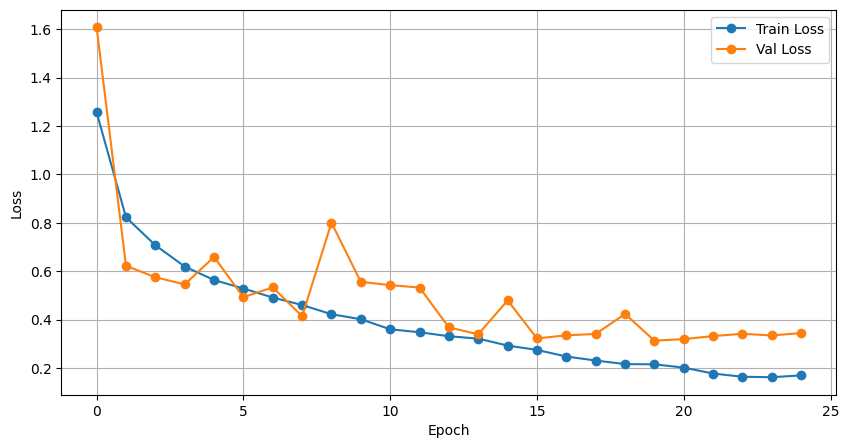

In [13]:
plt.figure(figsize=(10,5))

plt.plot(history['train_loss'], label='Train Loss', marker="o")
plt.plot(history['val_loss'], label='Val Loss', marker="o")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(conf.device)

with torch.no_grad():
    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

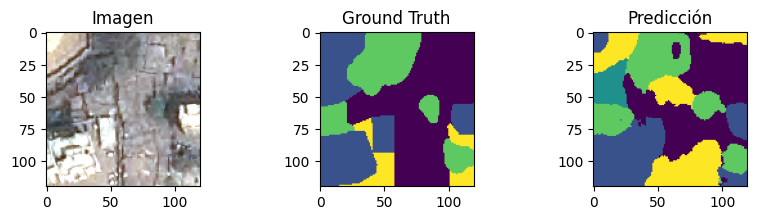

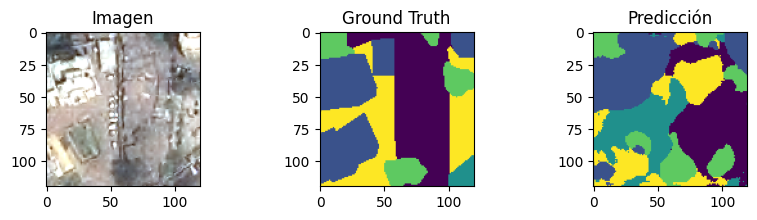

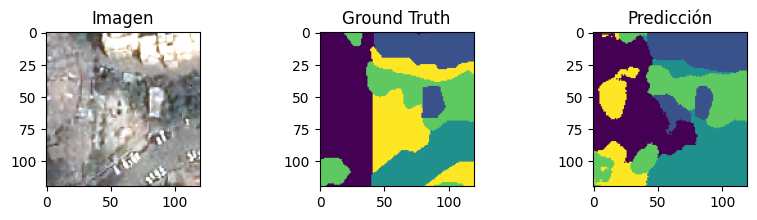

In [ ]:
n = 3

for i in range(n):
    fig, ax = plt.subplots(1,3, figsize=(10,2))

    ax[0].imshow(images[i].cpu().permute(1,2,0))
    ax[0].set_title("Imagen")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    ax[1].imshow(masks[i].cpu())
    ax[1].set_title("Ground Truth")
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    ax[2].imshow(preds[i].cpu())
    ax[2].set_title("Predicción")
    ax[2].set_xticks([])
    ax[2].set_yticks([])

    plt.show()

In [27]:
def dice_score(preds, targets, num_classes, smooth=1e-6):
    dices = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()

        dice = (2.0 * intersection + smooth) / (
            pred_cls.sum() + target_cls.sum() + smooth
        )

        dices.append(dice)
    return torch.mean(torch.stack(dices))

In [34]:
def calc_dice(model, val_loader, config):
    model.eval()
    dice_total = 0
    num_batches = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(conf.device)
            masks = masks.to(conf.device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            dice_total += dice_score(
                preds,
                masks,
                num_classes=7
            )

            num_batches += 1
    return (dice_total / num_batches).item()

print(f"Dice: {calc_dice(model, val_loader, conf):.4f}")

Dice: 0.7508


In [29]:
def iou_score(preds, targets, num_classes, smooth=1e-6):
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        union = (pred_cls | target_cls).sum()
        if union == 0:
            continue

        intersection = (pred_cls & target_cls).sum().float()

        iou = (intersection + smooth) / (union.float() + smooth)
        ious.append(iou)
    return torch.mean(torch.stack(ious))

In [33]:
def calc_iou(model, val_loader, config):
    model.eval()

    iou_total = 0
    num_batches = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(conf.device)
            masks = masks.to(conf.device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            iou_total += iou_score(
                preds,
                masks,
                num_classes=7
            )

            num_batches += 1

    return (iou_total / num_batches).item()
print(f"IoU: {calc_iou(model, val_loader, conf):.4f}")

IoU: 0.6249


In [37]:
torch.save(model.state_dict(), "baseline_1.pth")